In [1]:
# Setup

# import os
# from prophet import Prophet

# env_path = r"C:\Users\Kura\anaconda3\envs\prophet"
# extra_paths = [
#     env_path,
#     os.path.join(env_path, "Library", "mingw-w64", "bin"),
#     os.path.join(env_path, "Library", "usr", "bin"),
#     os.path.join(env_path, "Library", "bin"),
#     os.path.join(env_path, "Scripts"),
# ]
# os.environ["PATH"] = os.pathsep.join(extra_paths) + os.pathsep + os.environ["PATH"]

In [2]:
import pandas as pd
from prophet import Prophet


df = pd.read_csv("airline-passengers.csv")
df['Month'] = pd.to_datetime(df['Month'], format="%Y-%m")
df = df.set_index('Month')

print(df.head())
print(df.info())

            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121
<class 'pandas.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB
None


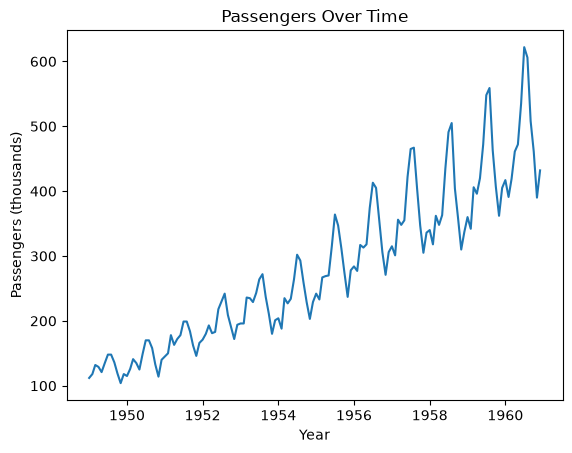

In [3]:
# Plot the Raw Data

import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(df.index, df.values)

plt.xlabel('Year')
plt.ylabel('Passengers (thousands)')
plt.title('Passengers Over Time')

plt.show()

# Trending upward with an uptick of passengers for every year

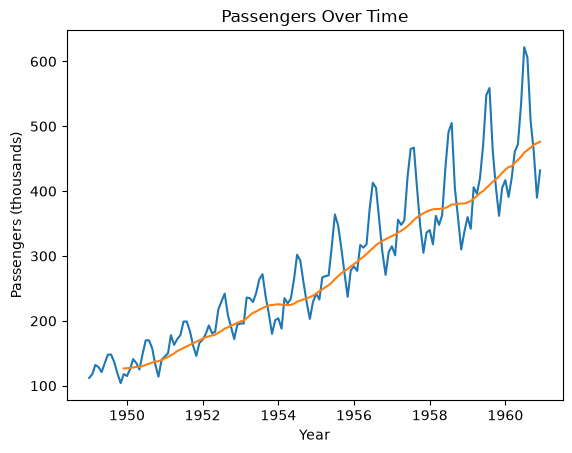

In [4]:
# Find the Trend by Eye

# The trend is going up

df['RollingMean'] = df['Passengers'].rolling(window=12).mean()

fig, ax = plt.subplots()

plt.plot(df.index, df['Passengers'])
plt.plot(df.index, df['RollingMean'])

plt.xlabel('Year')
plt.ylabel('Passengers (thousands)')
plt.title('Passengers Over Time')

plt.show()

# Makes the trend easier to see

C:\Users\jesse\AppData\Local\Temp\ipykernel_26684\3616371223.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(months)


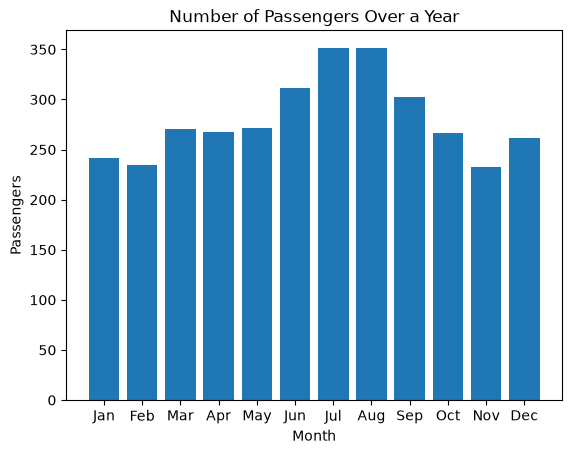

In [5]:
# Find the Seasonality by Line

month_avg = df.groupby(df.index.month)['Passengers'].mean()

months = df.index.strftime('%b')


fig, ax = plt.subplots()

ax.bar(month_avg.index, month_avg.values)
ax.set_xlabel('Month')
ax.set_ylabel('Passengers')
ax.set_xticklabels(months)
ax.set_xticks(month_avg.index)
ax.set_title('Number of Passengers Over a Year')

plt.show()

In [22]:
# Reformat the Data for Prophet

df_prophet = pd.read_csv('airline-passengers.csv')

df_prophet = df_prophet.rename(columns={"Month": "ds", "Passengers": "y"})
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])

print(df_prophet.head())

          ds    y
0 1949-01-01  112
1 1949-02-01  118
2 1949-03-01  132
3 1949-04-01  129
4 1949-05-01  121


08:26:38 - cmdstanpy - INFO - Chain [1] start processing
08:26:38 - cmdstanpy - INFO - Chain [1] done processing


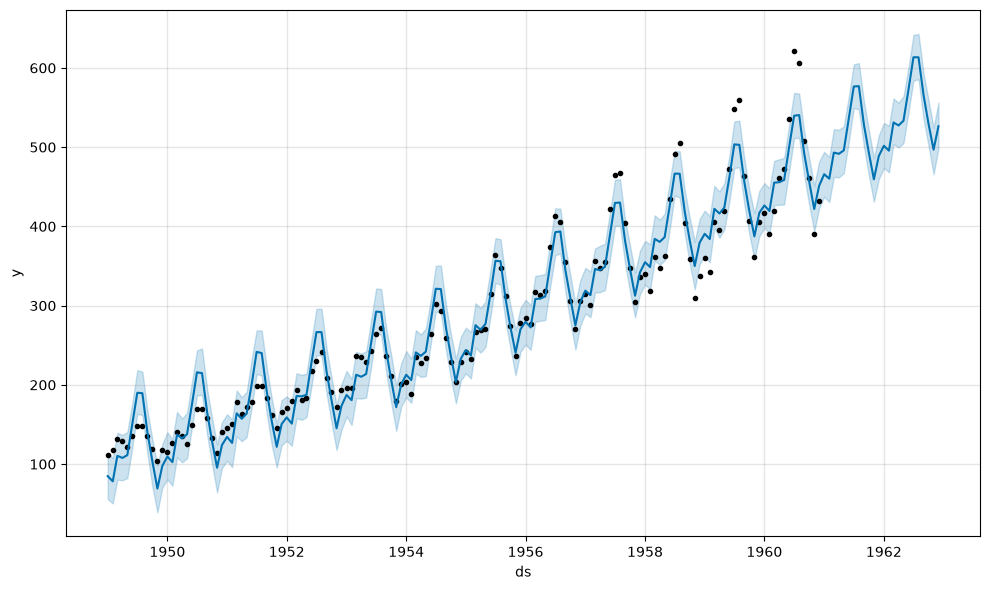

In [23]:
# Build your first Forecast

model = Prophet()
model.fit(df_prophet)
future = model.make_future_dataframe(periods=24, freq="MS")
forecast = model.predict(future)

fig = model.plot(forecast)
plt.show()

# The uncertainty band gets chunkier the further out it predicts.

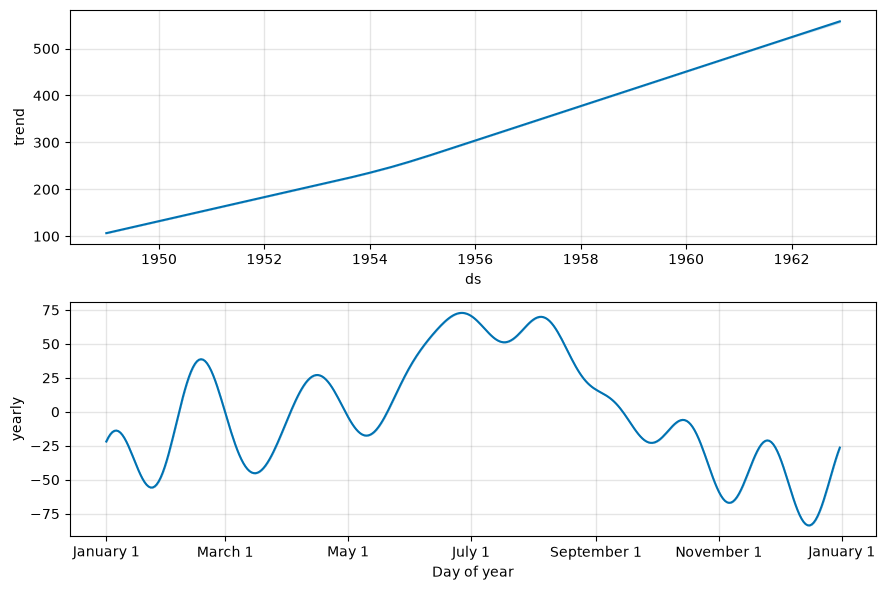

In [24]:
# Compare Components

fig2 = model.plot_components(forecast)
plt.show()

# Yes this plot matches what we saw. One curiosity is the dip in passengers between July 
# ## and August on the monthly graph. Explain ???

### Advanced Tasks

In [25]:
# Build a Fair Train/Test Split

# Every row except the last 12 months becomes the training set
train_df = df_prophet.iloc[:-12].copy()

# The last 12 months become the test set
test_df = df_prophet.iloc[-12:].copy()

print("Last train date:", train_df["ds"].max())
print("First test date:", test_df["ds"].min())

Last train date: 1959-12-01 00:00:00
First test date: 1960-01-01 00:00:00


In [30]:
new_model = Prophet()
new_model.fit(train_df)

new_future = new_model.make_future_dataframe(periods=12, freq="MS")
new_forecast = new_model.predict(future)
# print(new_forecast[["ds", "yhat"]].tail(12))

comparison = test_df.merge(new_forecast[["ds", "yhat"]], on='ds')
comparison.head()

mae = (comparison["y"] - comparison["yhat"]).abs().mean()

print(f'MAE: {mae}')

08:28:00 - cmdstanpy - INFO - Chain [1] start processing
08:28:00 - cmdstanpy - INFO - Chain [1] done processing


MAE: 33.443397579857155


`Spot the Data Leakage`  
Don't randomize the data, ***DENISE***.  
This is an example of data leakage because the model would be able to learn from info that shouldn't be available "yet" according to the time that we are predicting. Training on future information would give false confidence in a prediction made anywhere in that date range.  
A chronological split avoids this by deciding a specific date and only training on "past" data and predicting on "future" data, keeping the integrity of a test prediction to check accuracy.

### Extra Credit

In [31]:
def forecast_evaluator(df, num_months):

    #Train-Test Split
    train_df = df.iloc[:-num_months].copy()
    test_df = df.iloc[-num_months:].copy()

    # Create/Train the model
    model = Prophet()
    model.fit(train_df)

    # Predict and Compare
    future = model.make_future_dataframe(periods=num_months, freq="MS")
    forecast = model.predict(future)
    comparison = test_df.merge(forecast[["ds", "yhat"]], on='ds')
    comparison.head()

    mae = (comparison["y"] - comparison["yhat"]).abs().mean()

    return model, forecast, mae

check_model, check_forecast, check_mae = forecast_evaluator(df_prophet, 12)

print(check_mae)

08:38:10 - cmdstanpy - INFO - Chain [1] start processing
08:38:10 - cmdstanpy - INFO - Chain [1] done processing


33.443397579857155


In [40]:
for num in [6, 12, 24, 48, 60, 120]:
    check_model, check_forecast, check_mae = forecast_evaluator(df_prophet, num)
    print(f'Months: {num}  ||  MAE: {check_mae}')

08:47:59 - cmdstanpy - INFO - Chain [1] start processing
08:47:59 - cmdstanpy - INFO - Chain [1] done processing
08:47:59 - cmdstanpy - INFO - Chain [1] start processing
08:47:59 - cmdstanpy - INFO - Chain [1] done processing
08:47:59 - cmdstanpy - INFO - Chain [1] start processing
08:47:59 - cmdstanpy - INFO - Chain [1] done processing


Months: 6  ||  MAE: 43.42884706427014
Months: 12  ||  MAE: 33.443397579857155
Months: 24  ||  MAE: 31.168305398178934


08:47:59 - cmdstanpy - INFO - Chain [1] start processing
08:47:59 - cmdstanpy - INFO - Chain [1] done processing
08:47:59 - cmdstanpy - INFO - Chain [1] start processing


Months: 48  ||  MAE: 37.80491906599165


08:47:59 - cmdstanpy - INFO - Chain [1] done processing
08:47:59 - cmdstanpy - INFO - Chain [1] start processing
08:47:59 - cmdstanpy - INFO - Chain [1] done processing


Months: 60  ||  MAE: 30.949046686842447
Months: 120  ||  MAE: 107.05798346432685


**Expected (logical) answer**: The more data that you hold out from the training set and predict on, the less accurate your predictions will be. Giving the model less data points to learn from and forcing it to predict further into the future will cause more uncertainty.  
**Actual results**: The predictions seem to get more accurate with more months being taken from the training set and added to the test set - at least up to five years. This could be caused by the variation in the true data, where the model predicts too extreme in the early years and too small in later years, so that the model is more accurate because it's not trying to fit on the large variation in the seasonality.

### Confusion ???

08:45:25 - cmdstanpy - INFO - Chain [1] start processing
08:45:25 - cmdstanpy - INFO - Chain [1] done processing


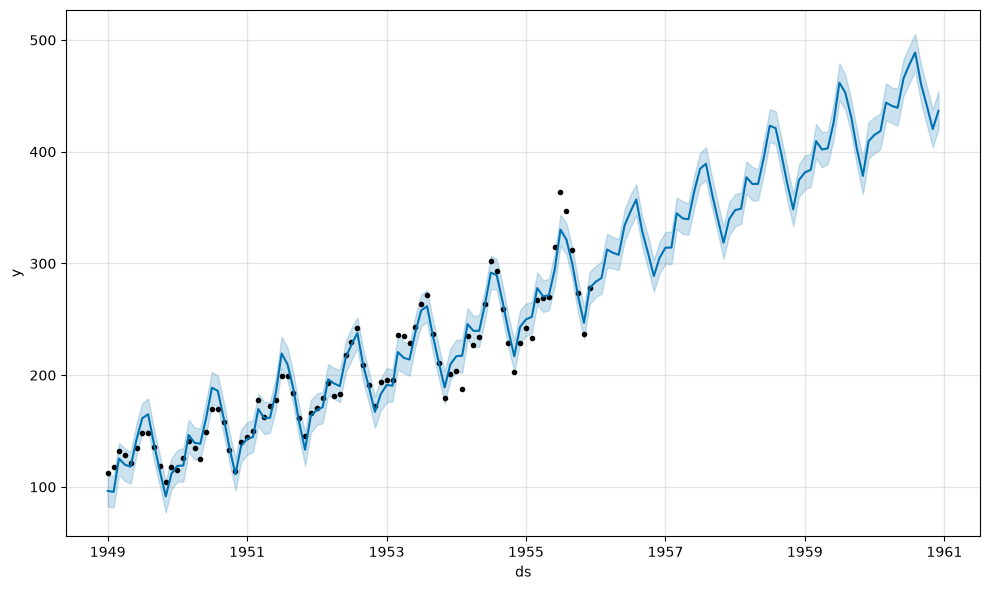

In [39]:
#Train-Test Split
train_df = df_prophet.iloc[:-60].copy()
test_df = df_prophet.iloc[-60:].copy()

# Create/Train the model
model = Prophet()
model.fit(train_df)

# Predict and Compare
future = model.make_future_dataframe(periods=60, freq="MS")
forecast = model.predict(future)
comparison = test_df.merge(forecast[["ds", "yhat"]], on='ds')
comparison.head()

fig = model.plot(forecast)
plt.show()

mae = (comparison["y"] - comparison["yhat"]).abs().mean()